In [1]:
import scanpy as sc
import sys
sys.path.append('/Users/amossi/Documents/code')
import FISHspace as sp
from scipy.spatial import KDTree
import numpy as np
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

# make font changeable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2


/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [ ]:
#adata = sc.read_h5ad('../../EEL_AnnData/EEL_41CleanNuclei-CellularNgh_FeaturesMN.h5ad')
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)
adata.obs['m-states'] = pd.Categorical(['Mural' if x.count('Mural') else x for x in adata.obs['m-states']])


In [3]:
adata.obs['m-states'].cat.categories

Index(['AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5',
       'AC-like 6', 'AC-like 7', 'Astrocyte', 'DC', 'Endothelial',
       'Erythrocyte', 'FB-like 1', 'FB-like 2', 'FB-like 3', 'GBL-like 1',
       'GBL-like 2', 'Mono 1', 'Mono 2', 'Mural', 'OPC-like 1', 'OPC-like 2',
       'Oligodendrocyte', 'RG-like', 'TAM-BDM 1', 'TAM-BDM 2', 'TAM-BDM 3',
       'TAM-BDM 4', 'TAM-MG', 'WR 1', 'WR 2', 'WR 3', 'WR 4', 'WR 5', 'WR 6',
       'WR 7', 'WR 8', 'nIPC-RG-like', 'nIPC-like 1', 'nIPC-like 2',
       'nIPC-like 3', 'preOPC-like', 'unknown'],
      dtype='object')

In [4]:
sadata= adata[adata.obs.Sample == 'SL016A']

In [5]:
gliosarcoma_palette = {
    'RG-like': '#93faa5',
     'nIPC-RG-like': '#93faa5',

    
    
    'FB-like 3': '#89c4f4',#'#FF6EC7',
    'FB-like 2': '#89c4f4',#'#FF6EC7',
        

    'WR 2': '#EDE8F3',
    'WR 3': '#E2D8EA',
    'WR 1': '#D6BEDD',
    'WR 5': '#CFA8D1',
    'WR 4': '#CA90C5',
    'WR 7': '#D873B6',

    'WR 8': '#C50F53',
    'WR 6': '#d2527f',

    'Endothelial': '#8c14fc',
    
    'AC-like 1':'#f2784b', #'#ffffcc',
    'AC-like 2':'#f2784b', #'#ffffcc',
    'AC-like 3':'#f2784b', #'#ffffcc',
    'AC-like 4':'#f2784b', #'#ffffcc',
    'AC-like 5':'#f2784b', #'#ffffcc',
    'AC-like 6':'#f2784b', #'#ffffcc',
    'AC-like 7':'#f2784b', #'#ffffcc',
}



INFO:root:First filter, 45798 cells left
INFO:root:Zoom filter, 45798 cells left


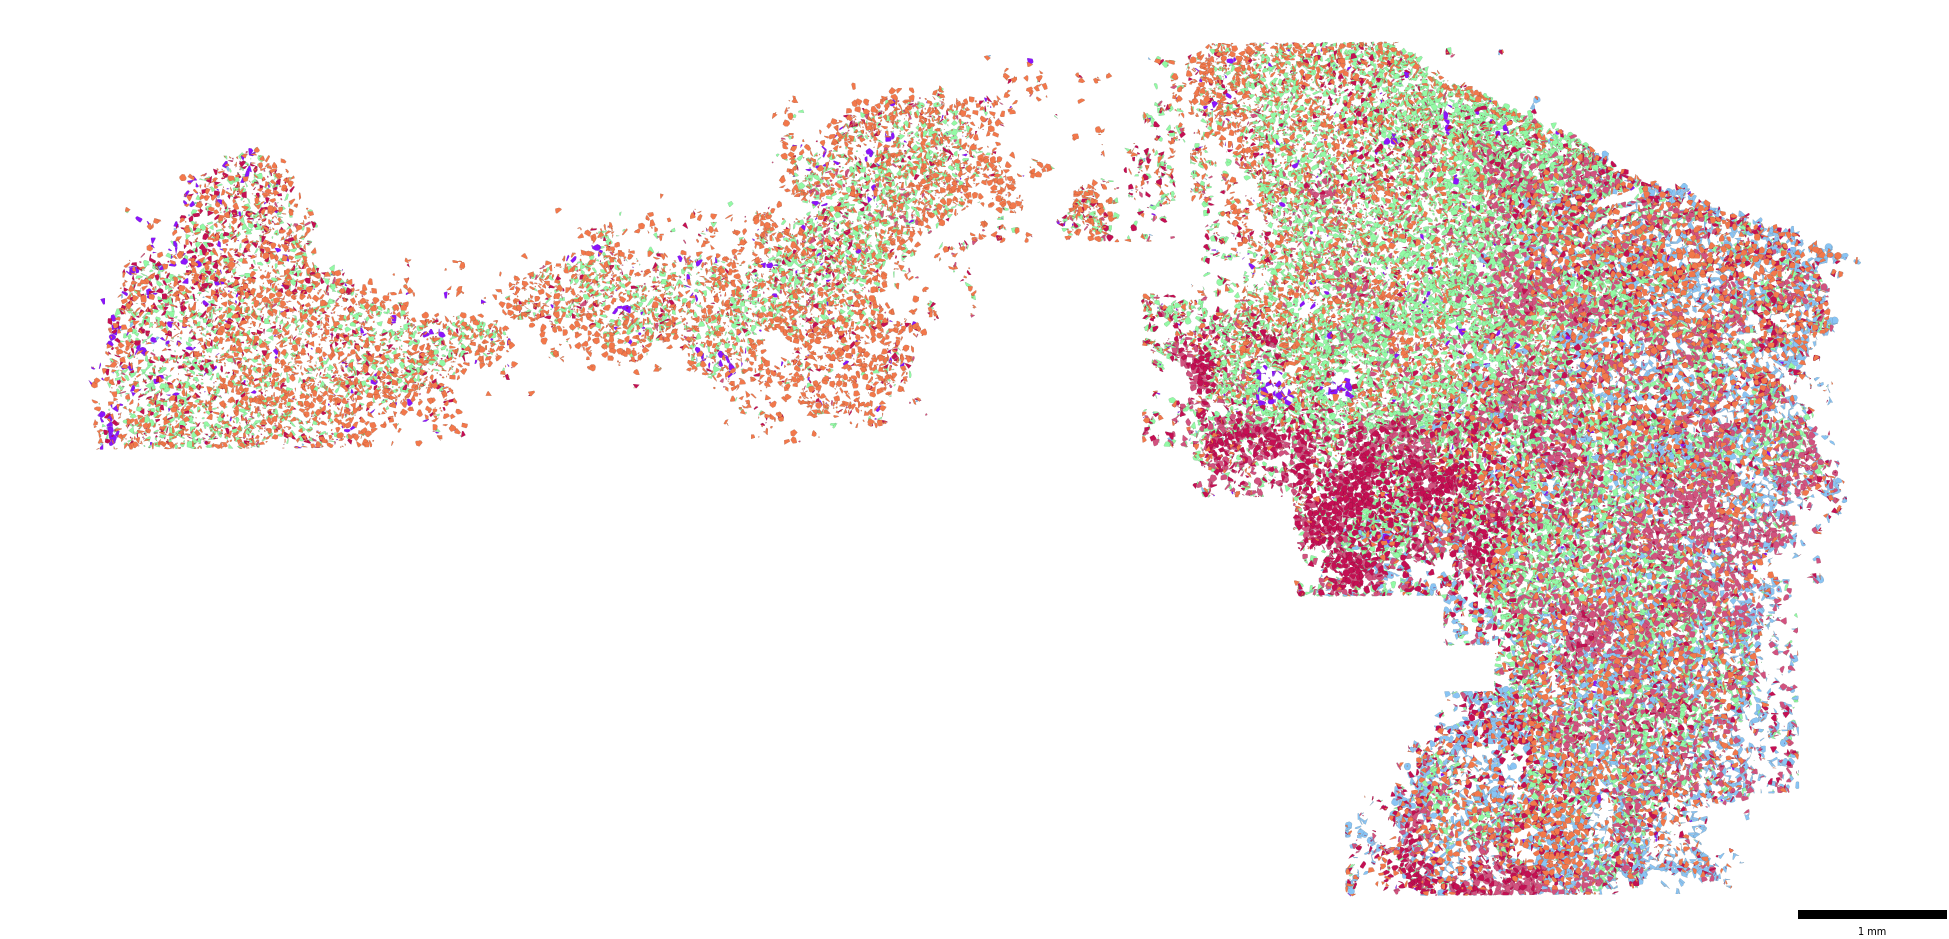

In [6]:
sp.pl.plot_polygons(
    adata,
    sample = 'SL016A',
    cluster_key='m-states',
    geometry_key='Polygons',
    clusters=['RG-like','Endothelial', 'FB-like 3', 'WR 6', 'WR 8', 'AC-like 1', 'AC-like 2', 'AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 7', 'WR 3'],
    markersize=10,
    alpha=1,
    area_min_size=5,
    palette= gliosarcoma_palette,
    save=True,
    figsize=(20,20),
    savepath='figures/SL016A.svg'
    
)

INFO:root:First filter, 46521 cells left
INFO:root:Zoom filter, 46521 cells left


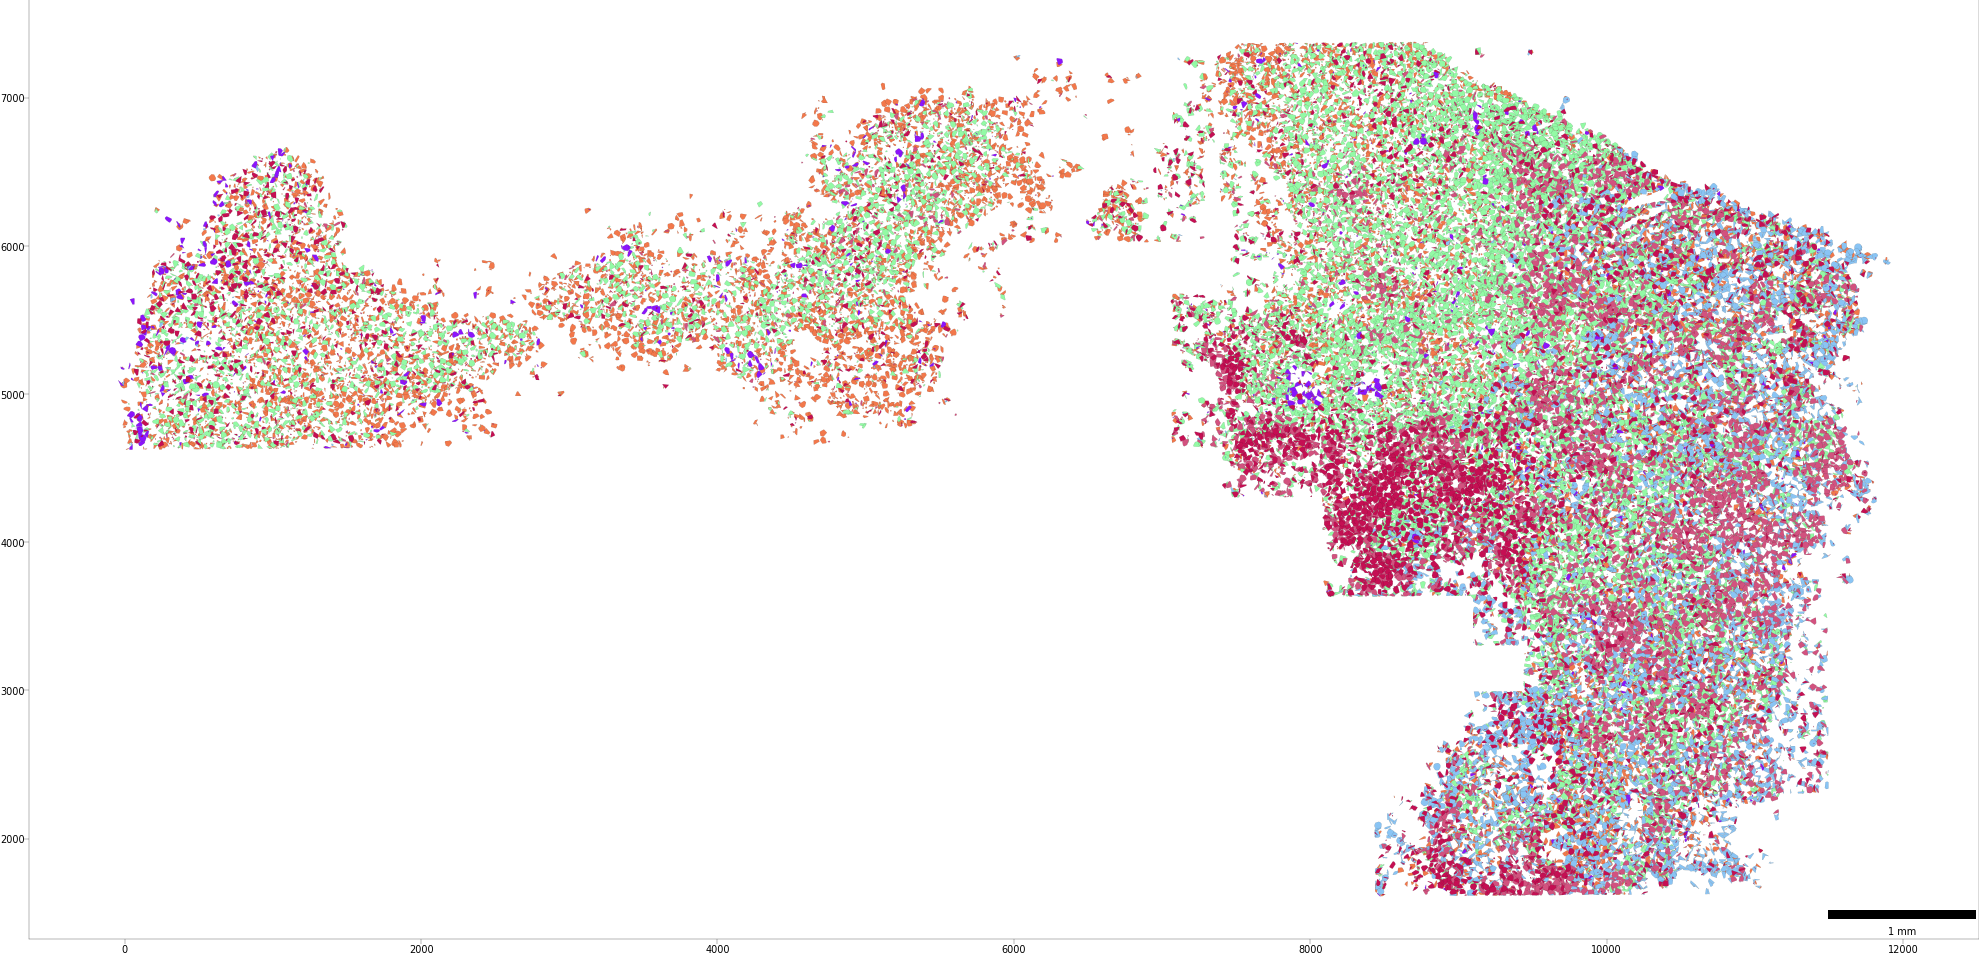

In [18]:
sp.pl.plot_polygons(
    adata,
    sample = 'SL016A',
    cluster_key='m-states',
    geometry_key='Polygons',
    clusters=[ 'AC-like 1', 'AC-like 2', 'AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 7', 'RG-like','nIPC-RG-like','Endothelial', 'FB-like 3', 'WR 6', 'WR 8','WR 3'],
    markersize=10,
    alpha=1,
    area_min_size=5,
    palette= gliosarcoma_palette,
    figsize=(20,20),
    show_axis=True

    
)

INFO:root:First filter, 94794 cells left
INFO:root:Zoom filter, 94794 cells left
INFO:root:Expression range: 1.0 - 7.0


Expression range:  1.0 7.0
vmax set to  7.0


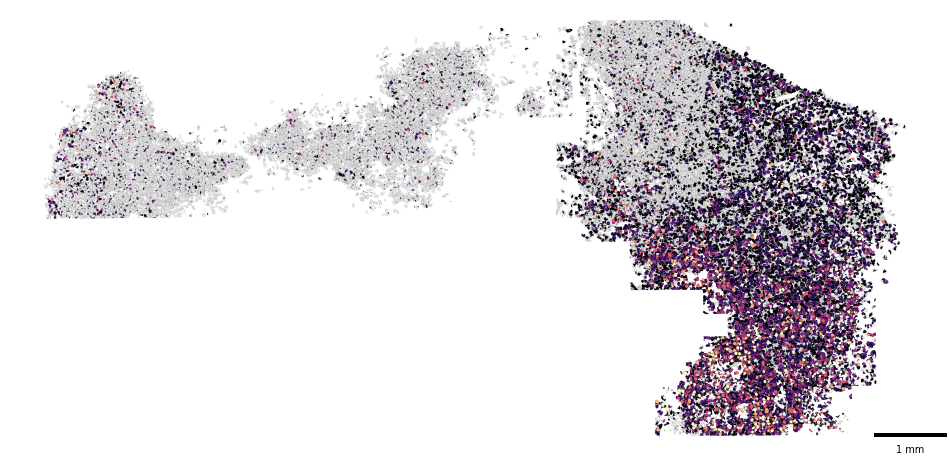

In [13]:
sp.pl.plot_polygons_expression(
    adata,
    sample = 'SL016A',
    cluster_key='m-states',
    genes = ['TIMP1'],
    cmap='magma',
    alpha=1,
    area_min_size=5,
    figsize=(10,10),
    mquant=0.999,
    #vmax=100,
    show_axis=False,
    save=True,
    savepath='figures/TIMP1.svg'
)

INFO:root:First filter, 47947 cells left
INFO:root:Zoom filter, 47947 cells left


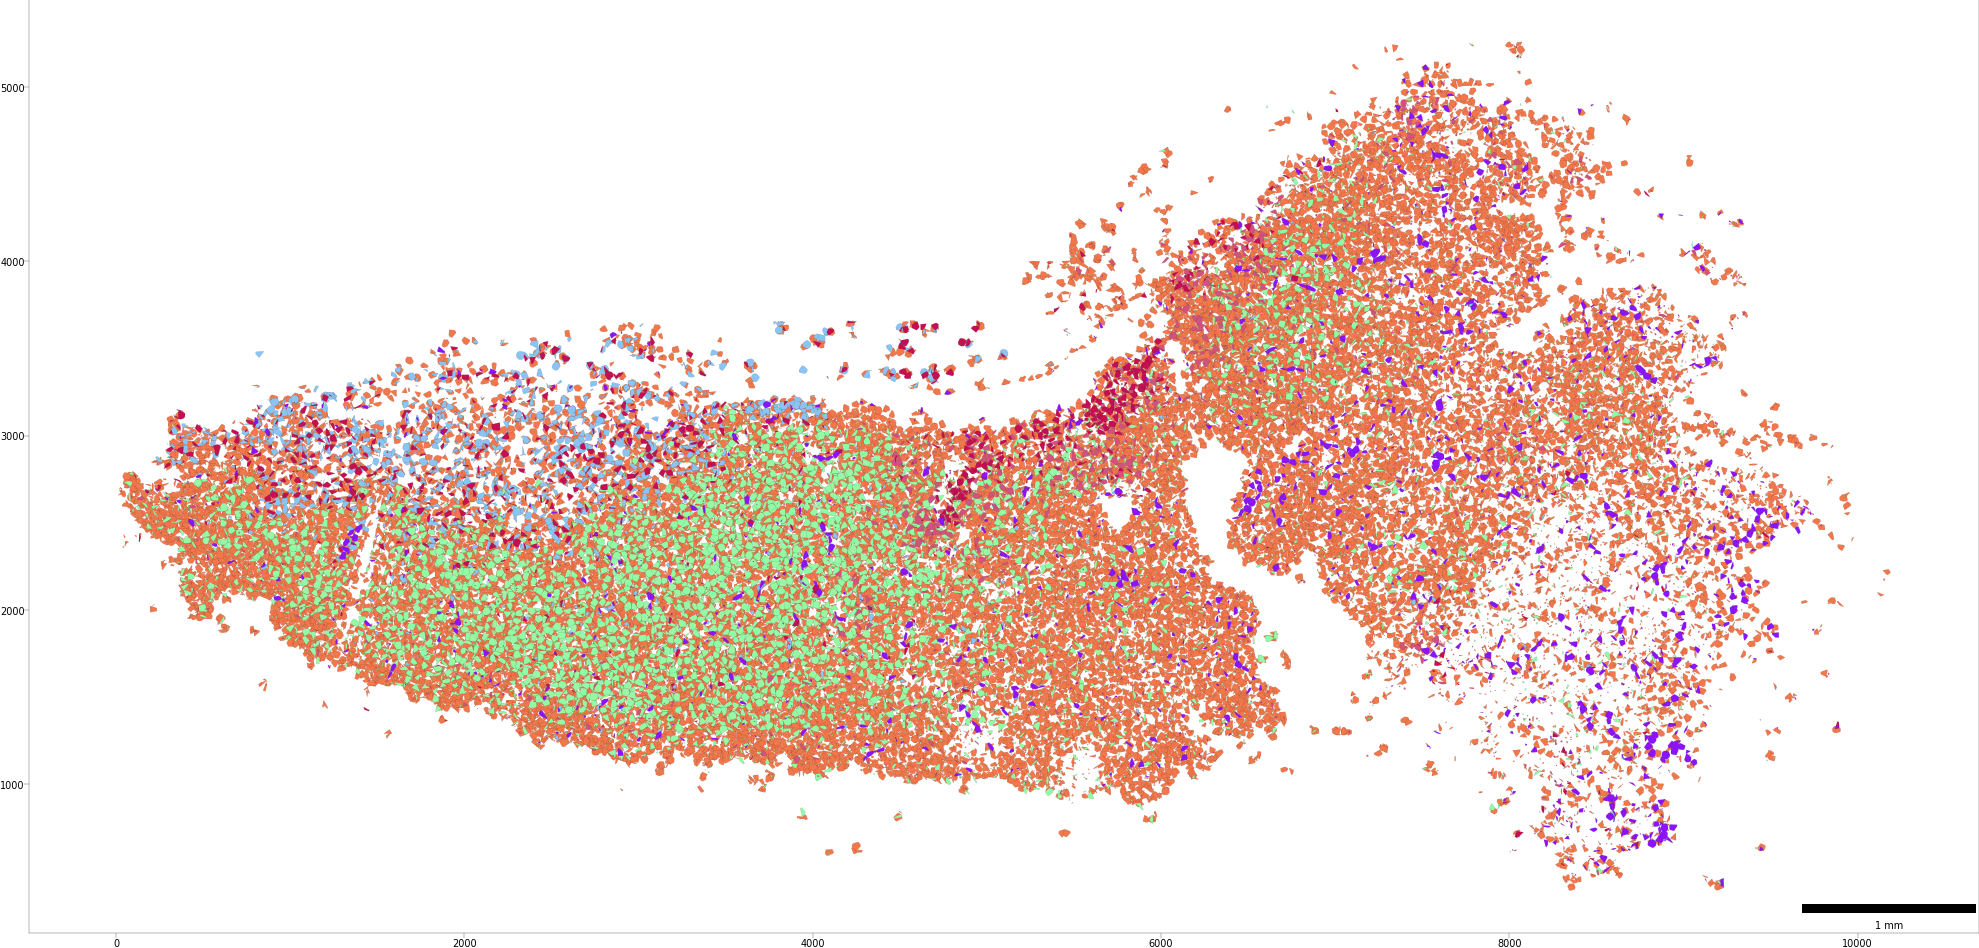

In [19]:
sp.pl.plot_polygons(
    adata,
    sample = 'SL020',
    cluster_key='m-states',
    geometry_key='Polygons',
    clusters=['AC-like 1', 'AC-like 2', 'AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 7', 'FB-like 3', 'nIPC-RG-like','RG-like','WR 6', 'WR 8', 'WR 3','Endothelial',],
    markersize=10,
    alpha=1,
    area_min_size=5,
    palette= gliosarcoma_palette,
    figsize=(20,20),
    show_axis=True

    
)

INFO:root:First filter, 94794 cells left
INFO:root:Zoom filter, 94794 cells left
INFO:root:Expression range: 1.0 - 10.515625


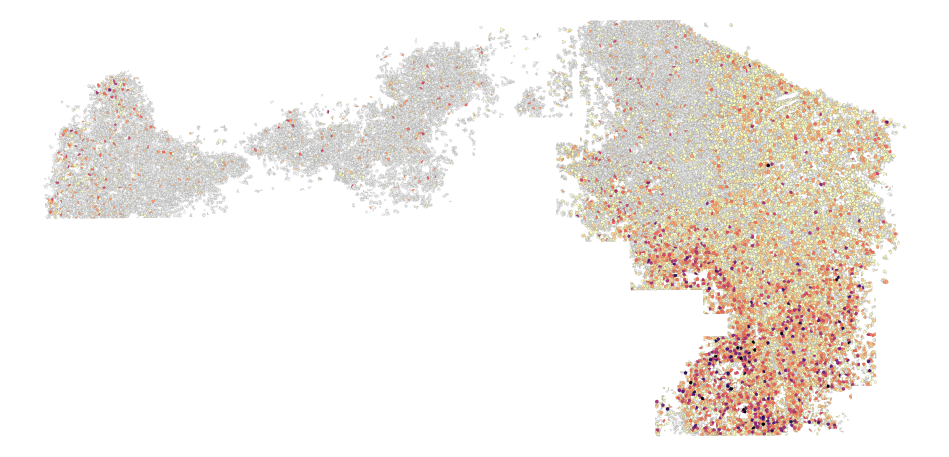

In [21]:
sp.pl.plot_polygons_expression(
    adata,
    sample = 'SL016A',
    cluster_key='m-states',
    genes = ['TIMP1'],
    cmap='magma_r',
    alpha=1,
    area_min_size=5,
    figsize=(10,10),
    mquant=0.9999,
    show_scalebar=False,
    show_axis=False,
    save=True,
    savepath='figures/SL016A_TIMP1.svg'
)